In [1]:
import tensorflow as tf 
from tensorflow.keras import layers 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#load dataset 

(x_train , x_test) , (y_train , y_test)= tf.keras.datasets.mnist.load_data()

x_train=x_train/255.0
x_train =x_train.reshape(x_train.shape[0] , 28 , 28 ,1)

In [3]:
#generator model 

def build_generator():

    model = tf.keras.Sequential(
        [
            layers.Dense(
                128 , activation="relu" , input_dim=100
            ),
            layers.Dense(784 , activation="sigmoid"),
            layers.Reshape((28,28,1))
        ]
    )

    return model 

In [5]:
# Discriminator Model


def build_discriminator():

    model = tf.keras.Sequential(
        [
            layers.Flatten(input_shape=(28, 28, 1)),
            layers.Dense(
                128, activation="relu"
            ),  
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    return model

In [6]:
#create model 

generator = build_generator()

discriminator = build_discriminator()

discriminator.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:

noise = np.random.normal(0, 1, (5, 100))  
generated_images = generator.predict(noise)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


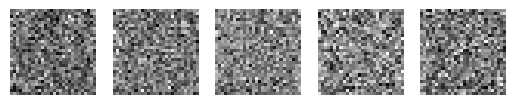

In [8]:
for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")

    plt.axis("off")

plt.show() 